# **Support Vector Machine** (SVM) for sentiment analysis

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

In [57]:
# ── Load data ────────────────────────────────────────────────────────────────
df_train = pd.read_csv("../reviews_train.csv")
df_test  = pd.read_csv("../reviews_test.csv")

X_train = df_train['clean_text']
X_test  = df_test['clean_text']
y_train = df_train['rating'].astype(int)
y_test  = df_test['rating'].astype(int)

print(f"Train: {len(X_train)} reviews")
print(f"Test:  {len(X_test)} reviews")
print("\nClass distribution (train):")
print(y_train.value_counts())


Train: 4525 reviews
Test:  1132 reviews

Class distribution (train):
rating
5    2316
1    1170
4     409
3     325
2     305
Name: count, dtype: int64


In [ ]:
# Build pipeline
# TF-IDF with unigrams and bigrams captures word combinations like
# "not good" or "very slow" which are important for sentiment.
# sublinear_tf dampens the effect of very frequent terms.

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50_000,
        sublinear_tf=True,
        min_df=2,
    )),
    ('svm', LinearSVC(
        C=1.0,
        max_iter=2000,
        class_weight='balanced',   # compensates for class imbalance
        random_state=42,
    ))
])

In [ ]:
# Training the model
pipeline.fit(X_train, y_train)
print("Training complete.")

Training complete.


In [60]:
# Evaluate
y_pred = pipeline.predict(X_test)

print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, digits=3))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           1      0.559     0.581     0.570       303
           2      0.062     0.061     0.062        66
           3      0.054     0.049     0.052        81
           4      0.124     0.113     0.118        97
           5      0.715     0.721     0.718       585

    accuracy                          0.545      1132
   macro avg      0.303     0.305     0.304      1132
weighted avg      0.537     0.545     0.541      1132



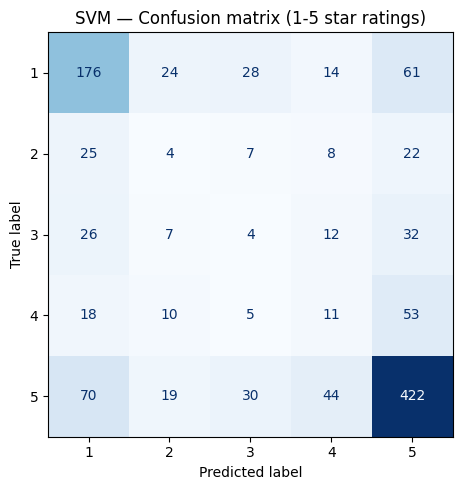

In [ ]:
# Confusion matrix
labels = [1, 2, 3, 4, 5]

cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("SVM — Confusion matrix (1-5 star ratings)")
plt.tight_layout()
plt.show()

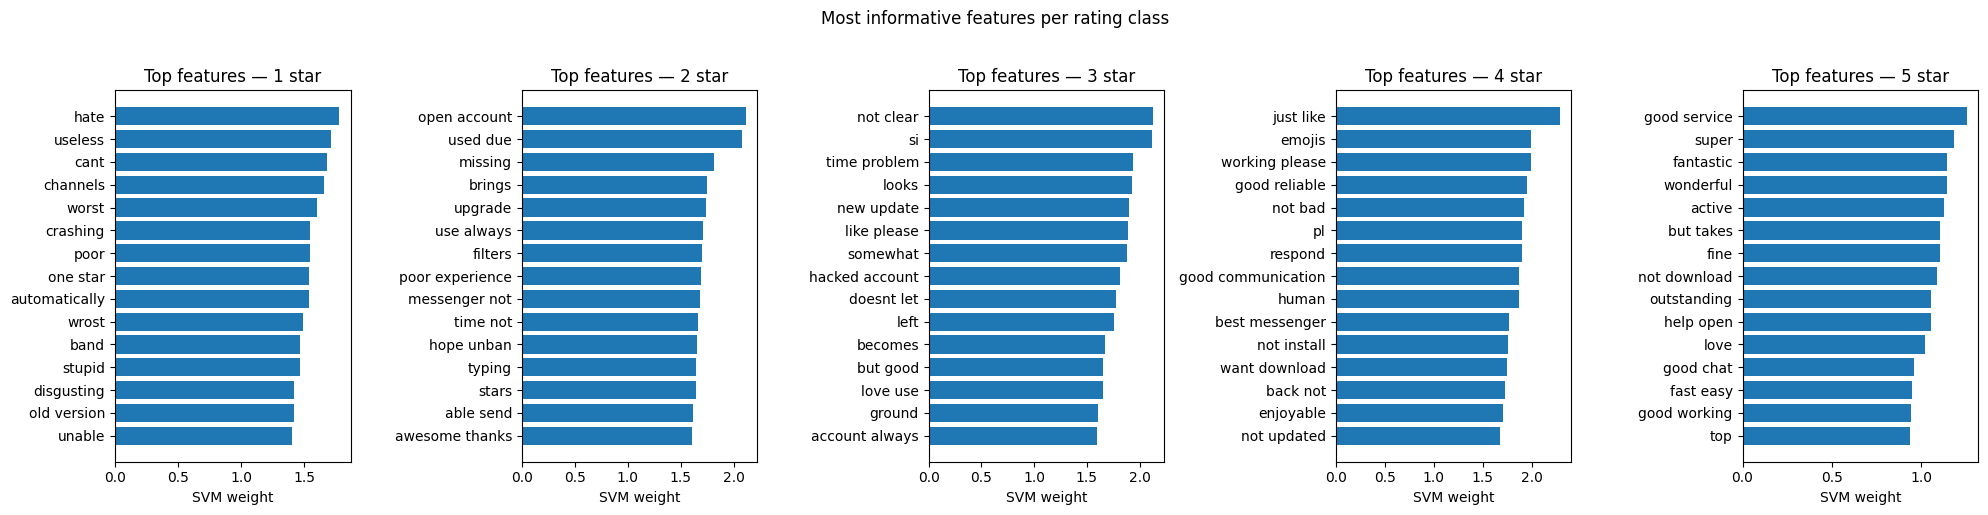

In [ ]:
# Most informative features
# SVM assigns weights to each feature (word/bigram).
# The highest weights tell us which words most strongly push
# the model toward each sentiment class.

# Most informative features
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
coef          = pipeline.named_steps['svm'].coef_   # shape: (5, n_features)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, (label, ax) in enumerate(zip(labels, axes)):
    top_idx    = np.argsort(coef[i])[-15:]
    top_words  = feature_names[top_idx]
    top_scores = coef[i][top_idx]

    ax.barh(top_words, top_scores)
    ax.set_title(f"Top features — {label} star")
    ax.set_xlabel("SVM weight")

plt.suptitle("Most informative features per rating class", y=1.02)
plt.tight_layout()
plt.show()

In [63]:
# ── Hyperparameter tuning (C value) ──────────────────────────────────────────
from sklearn.model_selection import cross_val_score

C_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
mean_scores = []

for C in C_values:
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=50_000,
            sublinear_tf=True,
            min_df=2,
        )),
        ('svm', LinearSVC(C=C, max_iter=2000, 
                          class_weight='balanced', 
                          random_state=42))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1_macro')
    mean_scores.append(scores.mean())
    print(f"C={C:<6} → F1 macro: {scores.mean():.4f} ± {scores.std():.4f}")

best_C = C_values[np.argmax(mean_scores)]
print(f"\nBest C: {best_C}")

C=0.01   → F1 macro: 0.2793 ± 0.0077
C=0.1    → F1 macro: 0.3393 ± 0.0136
C=0.5    → F1 macro: 0.3265 ± 0.0101
C=1.0    → F1 macro: 0.3220 ± 0.0110
C=2.0    → F1 macro: 0.3143 ± 0.0087
C=5.0    → F1 macro: 0.3034 ± 0.0069
C=10.0   → F1 macro: 0.2986 ± 0.0072

Best C: 0.1


In [ ]:
# Final model with best C
final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50_000,
        sublinear_tf=True,
        min_df=2,
    )),
    ('svm', LinearSVC(
        C=best_C,
        max_iter=2000,
        class_weight='balanced',
        random_state=42,
    ))
])

final_pipeline.fit(X_train, y_train)
y_pred_final = final_pipeline.predict(X_test)

print("=" * 50)
print(f"FINAL MODEL (C={best_C})")
print("=" * 50)
print(classification_report(y_test, y_pred_final, digits=3))

FINAL MODEL (C=0.1)
              precision    recall  f1-score   support

           1      0.566     0.703     0.627       303
           2      0.042     0.030     0.035        66
           3      0.063     0.049     0.056        81
           4      0.188     0.124     0.149        97
           5      0.768     0.762     0.765       585

    accuracy                          0.598      1132
   macro avg      0.325     0.334     0.326      1132
weighted avg      0.571     0.598     0.582      1132



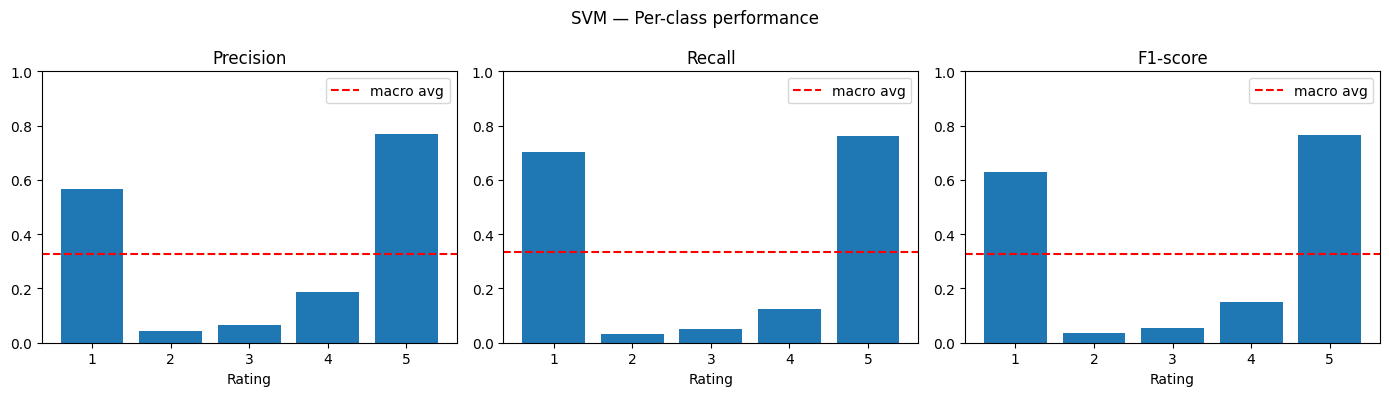

In [65]:
# Per-class performance
report = classification_report(y_test, y_pred_final,
                                output_dict=True,
                                labels=[1, 2, 3, 4, 5])

report_df = pd.DataFrame(report).T.loc[['1', '2', '3', '4', '5']]
report_df.index = [1, 2, 3, 4, 5]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric in zip(axes, ['precision', 'recall', 'f1-score']):
    ax.bar(report_df.index, report_df[metric])
    ax.set_title(metric.capitalize())
    ax.set_xlabel("Rating")
    ax.set_ylim(0, 1)
    ax.axhline(y=report_df[metric].mean(), color='red',
               linestyle='--', label='macro avg')
    ax.legend()

plt.suptitle("SVM — Per-class performance")
plt.tight_layout()
plt.show()

Error distance distribution:
  Off by 0 stars:  677 (59.8%)
  Off by 1 stars:  163 (14.4%)
  Off by 2 stars:  117 (10.3%)
  Off by 3 stars:   56 (4.9%)
  Off by 4 stars:  119 (10.5%)

Mean absolute error:    0.920 stars
Exact match:            0.598
Within 1 star:          0.742


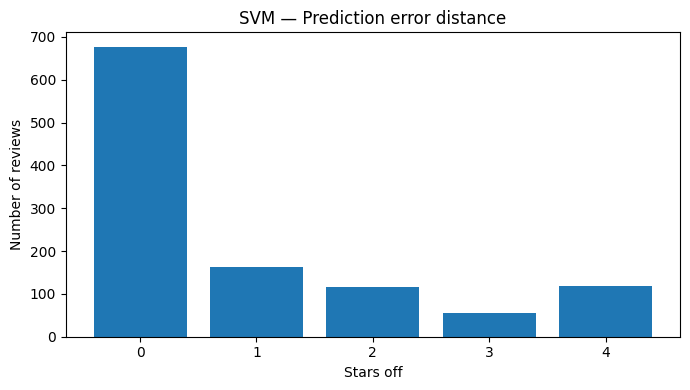

In [ ]:
# Error distance
df_test_results = df_test.copy()
df_test_results['predicted'] = y_pred_final
df_test_results['error_distance'] = abs(y_test - y_pred_final)

print("Error distance distribution:")
dist = df_test_results['error_distance'].value_counts().sort_index()
for d, count in dist.items():
    pct = count / len(df_test_results) * 100
    print(f"  Off by {d} stars: {count:4d} ({pct:.1f}%)")

print(f"\nMean absolute error:    {df_test_results['error_distance'].mean():.3f} stars")
print(f"Exact match:            {(df_test_results['error_distance'] == 0).mean():.3f}")
print(f"Within 1 star:          {(df_test_results['error_distance'] <= 1).mean():.3f}")

# Visualise error distances
plt.figure(figsize=(7, 4))
plt.bar(dist.index, dist.values)
plt.xlabel("Stars off")
plt.ylabel("Number of reviews")
plt.title("SVM — Prediction error distance")
plt.xticks([0, 1, 2, 3, 4])
plt.tight_layout()
plt.show()

In [67]:
# Error analysis what the model ges wrong 
wrong = df_test_results[df_test_results['error_distance'] > 0]

print(f"Total misclassified: {len(wrong)} / {len(df_test_results)}")
print()
print("Most common confusion pairs (true → predicted):")
error_pairs = wrong.groupby(['rating', 'predicted']).size().sort_values(ascending=False)
print(error_pairs.head(10))
print()
print("Example misclassified reviews:")
for _, row in wrong.sample(100, random_state=42).iterrows():
    print(f"  True: {row['rating']}★  Predicted: {row['predicted']}★  | {str(row['clean_text'])[:80]}")

Total misclassified: 455 / 1132

Most common confusion pairs (true → predicted):
rating  predicted
5       1            82
4       5            52
1       5            37
2       1            33
3       1            28
        5            28
5       4            26
1       3            26
5       3            21
4       1            20
dtype: int64

Example misclassified reviews:
  True: 3★  Predicted: 4★  | absolutely fantastic but online mark added block solution add
  True: 2★  Predicted: 1★  | very hassle im log today tomorrow cant open may account spam hope fix
  True: 3★  Predicted: 1★  | pleasant recently sharing media like video pic select list sent without allowing
  True: 2★  Predicted: 1★  | misbehave sometimes trying add account but keeps showing loading fix please
  True: 4★  Predicted: 5★  | good experience
  True: 2★  Predicted: 3★  | ok clear
  True: 4★  Predicted: 5★  | please need change number oooo plz
  True: 4★  Predicted: 3★  | new
  True: 5★  Predicted: 4★  | ve

## Model choice and justification

This model was built to predict the review score (1-5 stars) from the review text alone. For this predictoin model we used a Support Vector Machine with a linear decision boundary (LinearSVC) because it is a strong baseline for text classification when the input is represented as sparse word features. Review text typically produces very high-dimensional feature spaces, and linear SVMs usually perform well in this setting while also being relatively fast to train.

### Why TF-IDF was used

The review text was transformed with TF-IDF, because this representation gives more weight to informative words and reduces the influence of very common words. We used unigrams and bigrams (ngram_range=(1,2)) so the model could learn both single words and short phrases such as "not good", "very bad", or "high quality", which are important for sentiment and rating prediction. We also set sublinear_tf=True to dampen the effect of extremely frequent terms, min_df=2 to remove very rare noise terms, and max_features=50_000 to keep the representation large enough to capture useful patterns without becoming unnecessarily expensive.

### Why class_weight='balanced' was used

The training data is clearly imbalanced. For example, the 5-star class is much larger than the 2-star and 3-star classes. Without compensation, the model would tend to favor the majority classes. We therefore used class_weight='balanced', which gives more importance to underrepresented classes during training.

### Hyperparameter choice

We tuned the regularization parameter C using 5-fold cross-validation and selected the value that gave the best macro F1-score. We used macro F1 for tuning because it treats all classes equally and is therefore more appropriate than accuracy when class sizes are uneven. The search showed that C = 0.1 performed best, so this was used in the final model.

### Evaluation and interpretation

The final SVM achieved approximately 0.598 accuracy, 0.326 macro F1, and 0.582 weighted F1 on the test set. These results show that the model captures useful sentiment patterns, but performance is not equally strong across all rating levels. The model performs best on the 1-star and 5-star reviews, while the middle classes (2-4 stars) are much harder to separate. This is expected, because extreme reviews often contain clearer sentiment language, whereas middle ratings tend to use more mixed or neutral language. This becomes evidently when we look at the top bigrams for each rating class. Addiotionally, from the error analysis of the model, it becomes clear that much of the review data where low quality, ambigious and not matching the given rating. Forexample, an entry which had rating 4, had this review text: "yutube link thumbnail not supported version" which does not indicates a 4 in rating. The confusion matrix clearly shows that it most commonly confuses rating 1 with rating 5 and vica versa. This  the model confuses

To evaluate the model, we used:

- Accuracy to measure overall correctness.
- Precision, recall, and F1-score per class to see how well each rating was predicted.
- Macro F1 to assess balanced performance across all classes.
- Weighted F1 to account for class imbalance.
- Confusion matrix to inspect which ratings the model confuses most often.

Overall, this SVM is a solid and interpretable traditional machine learning model for this task. It gives a strong text-classification baseline and is especially useful to compare against more complex models such as neural networks.